***Student1:*** Hammani Abdeslem

***Student2:*** Fellah mahdi

# Advanced Machine Learning — TP : Transfer Learning 
**Phase:** Phase 2 — Spatial Adaptation  
**Framework:** TensorFlow / Keras  
**Duration:** 2 hours

---

## Learning Objectives
By the end of this lab you will be able to:
1. Understand and simulate different types of **domain shift** (covariate, label, concept).
2. Separate a CNN into a **backbone** and a **classification head**.
3. Pretrain on a source domain and measure the **domain gap**.
4. Implement and compare **four transfer strategies**: Scratch, Feature Extraction, Gradual Unfreezing, Full Fine-tuning.
5. Apply **discriminative learning rates** (layer-wise LR schedule).
6. Apply transfer learning to a **medical imaging** challenge.

## Lab Rules
- Always use a **validation split** for hyperparameter decisions.
- Do **not** use the test set until the final evaluation.
- Report both accuracy and a short **critical analysis** for each strategy.

| Lab Part |  |
|---|---|
| Part 1 — Domain Shift | Domain Shift: Covariate, Label, Concept Shift |
| Part 2 — Dataset & Domain Creation |  Domain & Task |
| Part 3 — CNN Architecture | Why Transfer Works: Representation Hypothesis |
| Part 4 — Source Pretraining | Model Fine-Tuning|
| Part 5 — Label Budget | Training Data Scarcity |
| Part 6 — Transfer Strategies | Strategy Comparison Table |
| Part 7 — Discriminative LR | Discriminative Learning Rates (Howard & Ruder, 2018) |
| Part 8 — Visualization & Analysis |  |
| Challenge — Medical Imaging | Medical Image Classification |


## Part 0 — Setup & Imports

Run this cell first. All dependencies must be installed before starting.

In [1]:
import os, random, warnings
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import rotate as scipy_rotate
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers

warnings.filterwarnings('ignore')

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

NUM_CLASSES = 10
print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))


2026-04-19 01:44:55.220076: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-19 01:44:55.234345: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-19 01:44:55.771855: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow version: 2.20.0
GPU available: []


2026-04-19 01:44:59.737782: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


## Part 1 — Domain Shift: Theory & Visualization

The following cell visualizes **covariate shift** — the most common type and the one we address in this lab.


Dataset: (1797, 8, 8), classes: [0 1 2 3 4 5 6 7 8 9]


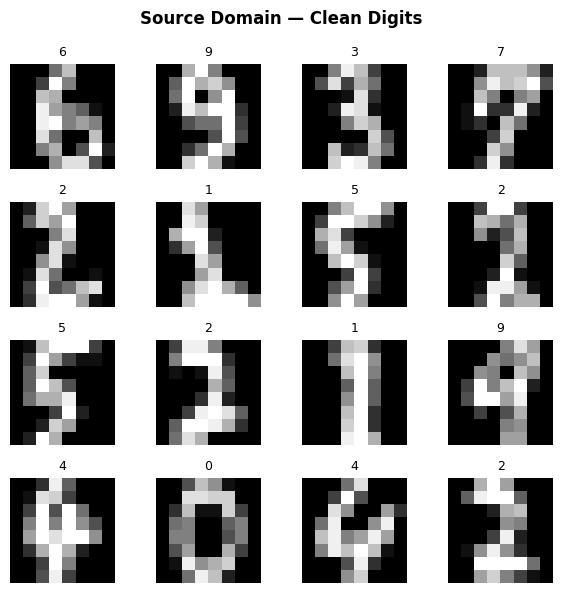

In [2]:
digits = load_digits()
X = digits.images.astype(np.float32)  # (N, 8, 8)
y = digits.target.astype(np.int64)
X = X / 16.0  # normalize to [0, 1]

print(f"Dataset: {X.shape}, classes: {np.unique(y)}")

def show_grid(images, labels, title, n=16):
    fig, axes = plt.subplots(4, 4, figsize=(6, 6))
    rng = np.random.RandomState(SEED)
    idx = rng.choice(len(images), n, replace=False)
    for i, ax in enumerate(axes.flat):
        ax.imshow(images[idx[i]], cmap='gray', vmin=0, vmax=1)
        ax.set_title(str(labels[idx[i]]), fontsize=9)
        ax.axis('off')
    fig.suptitle(title, fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

show_grid(X, y, "Source Domain — Clean Digits")


## Part 2 — Dataset & Domain Simulation

We simulate a **covariate shift** using the sklearn digits dataset:
- **Source domain:** clean digits (normal acquisition)
- **Target domain:** rotated + noisy digits (degraded sensor)

This mirrors the medical X-ray scenario: a model trained on clean scans fails when deployed with different equipment.


### 2.1 Create the Target Domain

> **TODO:** Implement `make_target_domain`.  
> Apply a rotation of `angle_deg` degrees and add Gaussian noise of std `noise_std`.  
> Clip the result to [0, 1].
>
> **Hints:**  
> - Use `scipy_rotate(img, angle=angle_deg, reshape=False, order=1, mode='constant', cval=0.0)`  
> - Add `np.random.normal(0, noise_std, img.shape)` to each rotated image  
> - Use `np.clip(..., 0.0, 1.0)` at the end


In [3]:
def make_target_domain(X: np.ndarray, angle_deg: float = 20.0, noise_std: float = 0.15) -> np.ndarray:
    """
    Simulate domain shift: rotation + Gaussian noise.

    Args:
        X         : (N, H, W) float32 in [0, 1]
        angle_deg : rotation angle in degrees
        noise_std : std of Gaussian noise

    Returns:
        Xt : (N, H, W) float32 in [0, 1]
    """
    rng = np.random.RandomState(SEED)
    result = []
    for img in X:
        rotated = scipy_rotate(img, angle=angle_deg, reshape=False, order=1, mode='constant', cval=0.0)
        noisy = rotated + rng.normal(0, noise_std, img.shape)
        result.append(np.clip(noisy, 0.0, 1.0))

    return np.array(result, dtype=np.float32)

# Test
X_target = make_target_domain(X, angle_deg=20.0, noise_std=0.15)
assert X_target.shape == X.shape, "Shape mismatch!"
assert X_target.min() >= 0.0 and X_target.max() <= 1.0, "Values out of [0, 1]!"
print("make_target_domain: OK")
print(f"X_target shape: {X_target.shape}, min: {X_target.min():.3f}, max: {X_target.max():.3f}")

make_target_domain: OK
X_target shape: (1797, 8, 8), min: 0.000, max: 1.000


### 2.2 Visualize Source vs Target

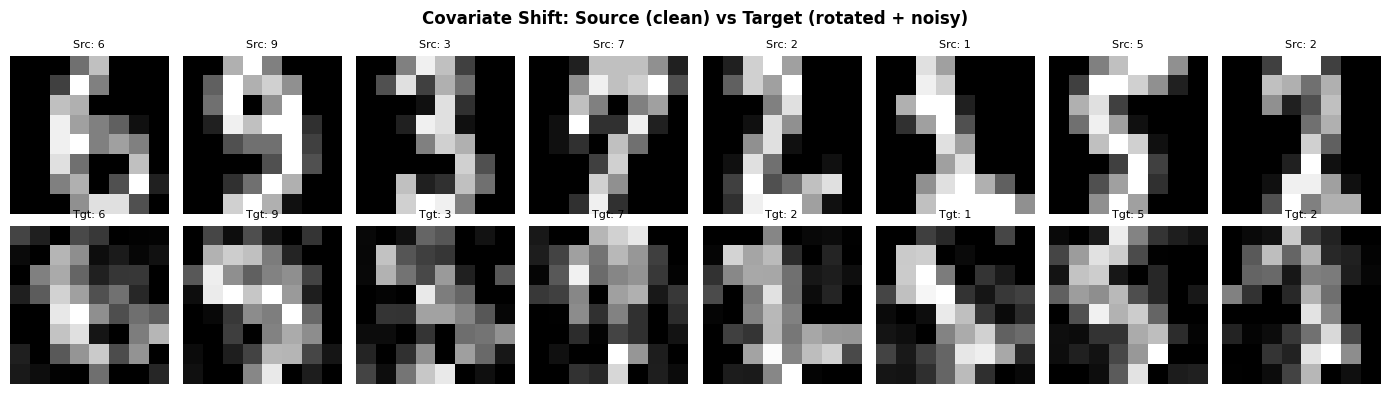

In [4]:
# Side-by-side comparison of source and target domains
rng = np.random.RandomState(SEED)
idx = rng.choice(len(X), 8, replace=False)
fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i, j in enumerate(idx):
    axes[0, i].imshow(X[j], cmap='gray', vmin=0, vmax=1)
    axes[0, i].set_title(f"Src: {y[j]}", fontsize=8)
    axes[0, i].axis('off')
    axes[1, i].imshow(X_target[j], cmap='gray', vmin=0, vmax=1)
    axes[1, i].set_title(f"Tgt: {y[j]}", fontsize=8)
    axes[1, i].axis('off')
axes[0, 0].set_ylabel("Source", fontsize=10)
axes[1, 0].set_ylabel("Target", fontsize=10)
fig.suptitle("Covariate Shift: Source (clean) vs Target (rotated + noisy)", fontweight='bold')
plt.tight_layout()
plt.show()


### 2.3 Train / Val / Test Split

In [5]:
# Split indices once — identical distributions in source and target
train_idx, test_idx = train_test_split(
    np.arange(len(X)), test_size=0.2, random_state=SEED, stratify=y)
train_idx, val_idx = train_test_split(
    train_idx, test_size=0.2, random_state=SEED, stratify=y[train_idx])

print(f"Train: {len(train_idx)} | Val: {len(val_idx)} | Test: {len(test_idx)}")

def make_tf_dataset(images, labels, indices, batch_size=32, shuffle=False):
    """Build a tf.data.Dataset from numpy arrays and index selection."""
    X_sub = images[indices][..., np.newaxis]  # (N, 8, 8, 1) — channel last
    y_sub = keras.utils.to_categorical(labels[indices], NUM_CLASSES)
    ds = tf.data.Dataset.from_tensor_slices(
        (X_sub.astype(np.float32), y_sub.astype(np.float32)))
    if shuffle:
        ds = ds.shuffle(len(indices), seed=SEED)
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

# Source datasets
ds_src_train = make_tf_dataset(X, y, train_idx, shuffle=True)
ds_src_val   = make_tf_dataset(X, y, val_idx, shuffle=False)
ds_src_test  = make_tf_dataset(X, y, test_idx, shuffle=False)

# Target datasets
ds_tgt_train = make_tf_dataset(X_target, y, train_idx, shuffle=True)
ds_tgt_val   = make_tf_dataset(X_target, y, val_idx, shuffle=False)
ds_tgt_test  = make_tf_dataset(X_target, y, test_idx, shuffle=False)

print("All 6 datasets created.")

Train: 1149 | Val: 288 | Test: 360
All 6 datasets created.


## Part 3 — CNN Architecture: Backbone + Head Separation

(Representation Hypothesis — Yosinski et al., 2014):
- **Early layers (backbone):** learn generic features (edges, textures) — transferable
- **Late layers (head):** learn task-specific features — need adaptation

**Architecture:**
```
Input (8, 8, 1)
  → Conv2D(32, 3, relu, same)  [backbone — conv1]
  → MaxPool2D(2)               [backbone — pool1]
  → Conv2D(64, 3, relu, same)  [backbone — conv2]
  → GlobalAveragePooling2D()   [backbone — gap]  ← feature vector (dim=64)
  → Dense(64, relu)            [head — dense1]
  → Dropout(0.3)
  → Dense(10, softmax)         [head — output]
```

**Fine-tuning objective:**
$$\min_{\theta} \; \mathcal{L}_T(\theta) + \lambda \|\theta - \theta_{\text{pretrained}}\|_2^2$$

- $\lambda \to \infty$: only head trains (Feature Extraction)
- $\lambda = 0$: unconstrained Full Fine-tuning
- $\lambda \in (0, \infty)$: controlled adaptation (L2 regularization)


### 3.1 Build Model

> **TODO:** Complete the model definition.  
> - Define the **backbone** layers (Conv2D + MaxPool + Conv2D + GAP).  
> - Set `trainable=not freeze_backbone` on backbone layers when needed.  
> - Define the **head** (Dense + Dropout + Dense) with optional L2 regularization.


In [6]:
def build_model(freeze_backbone: bool = False,
               l2_reg: float = 0.0,
               name: str = "SmallCNN") -> keras.Model:
    """
    Small CNN with separable backbone and head.

    Args:
        freeze_backbone : if True, backbone layers are non-trainable
        l2_reg          : L2 regularization coefficient on Dense layers
        name            : model name

    Returns:
        Compiled keras.Model
    """
    inputs = keras.Input(shape=(8, 8, 1), name="input")

    # -- BACKBONE --
    x = layers.Conv2D(32, 3, activation='relu', padding='same',
                      trainable=not freeze_backbone, name='conv1')(inputs)
    x = layers.MaxPooling2D(2, name='pool1')(x)
    x = layers.Conv2D(64, 3, activation='relu', padding='same',
                      trainable=not freeze_backbone, name='conv2')(x)
    features = layers.GlobalAveragePooling2D(name='gap')(x)

    # -- HEAD --
    reg = regularizers.l2(l2_reg) if l2_reg > 0 else None
    x = layers.Dense(64, activation='relu', kernel_regularizer=reg, name='dense1')(features)
    x = layers.Dropout(0.3, name='dropout')(x)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax', kernel_regularizer=reg, name='output')(x)

    model = keras.Model(inputs=inputs, outputs=outputs, name=name)
    model.compile(
        optimizer=keras.optimizers.Adam(1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# Sanity check
model_test = build_model()
model_test.summary()
print("\nTrainable params:", sum(np.prod(v.shape) for v in model_test.trainable_variables))

Model: "SmallCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 8, 8, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 8, 8, 32)       │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 4, 4, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 4, 4, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,626 (92.29 KB)

 Trainable params: 23,626 (92.29 KB)

 Non-trainable params: 0 (0.00 B)


Trainable params: 23626


### 3.2 Weight Transfer Utility

In [7]:
def transfer_weights(source_model: keras.Model,
                    target_model: keras.Model,
                    backbone_only: bool = False):
    """
    Copy weights from source_model to target_model.

    Args:
        source_model  : pretrained model
        target_model  : model to initialize
        backbone_only : if True, only copy backbone layers
    """
    backbone_layers = {'conv1', 'pool1', 'conv2', 'gap'}
    for layer in target_model.layers:
        if backbone_only and layer.name not in backbone_layers:
            continue
        try:
            src_w = source_model.get_layer(layer.name).get_weights()
            if src_w:
                layer.set_weights(src_w)
        except ValueError:
            pass  # layer not present in source

# Verify: transfer weights and check parameter counts
# (Will be used in Part 6 — do not call yet)
print("transfer_weights defined.")


transfer_weights defined.


## Part 4 — Source Pretraining

Train a model on the **source domain** (clean digits). Then evaluate it on both:
- **Source test** (in-domain) — expected high accuracy
- **Target test** (out-of-domain) — reveals the **domain gap**

> **TODO:** Build a fresh model, train for up to 40 epochs with EarlyStopping, evaluate on both test sets.


In [8]:
tf.random.set_seed(SEED)

model_src = build_model(name="src_pretrained")
history_src = model_src.fit(
    ds_src_train,
    validation_data=ds_src_val,
    epochs=40,
    callbacks=[keras.callbacks.EarlyStopping(patience=7,
               restore_best_weights=True, monitor='val_accuracy')],
    verbose=1
)
src_test_acc = model_src.evaluate(ds_src_test, verbose=0)[1]
tgt_test_acc = model_src.evaluate(ds_tgt_test, verbose=0)[1]
print(f"\nSource test accuracy : {src_test_acc:.3f}")
print(f"Target test accuracy : {tgt_test_acc:.3f}  <-- domain shift gap")
print(f"Domain gap           : {src_test_acc - tgt_test_acc:.3f}")

Epoch 1/40
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.1323 - loss: 2.2987 - val_accuracy: 0.1736 - val_loss: 2.2888
Epoch 2/40
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.1775 - loss: 2.2755 - val_accuracy: 0.1597 - val_loss: 2.2478
Epoch 3/40
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.2594 - loss: 2.2043 - val_accuracy: 0.5000 - val_loss: 2.1049
Epoch 4/40
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3847 - loss: 1.9917 - val_accuracy: 0.6562 - val_loss: 1.7641
Epoch 5/40
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5109 - loss: 1.6545 - val_accuracy: 0.8021 - val_loss: 1.3267
Epoch 6/40
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5901 - loss: 1.3342 - val_accuracy: 0.7986 - val_loss: 1.0425
Epoch 7/40
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6684 - loss: 1.1026 - val_accuracy: 0.8333 - val_loss: 0.8494
Epoch 8/40
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7111 - loss: 0.9345 - val_accuracy: 0.8090 - val_los

### 4.1 Plot Training Curves

> **TODO:** Plot the train/val loss and accuracy curves from `history_src`.

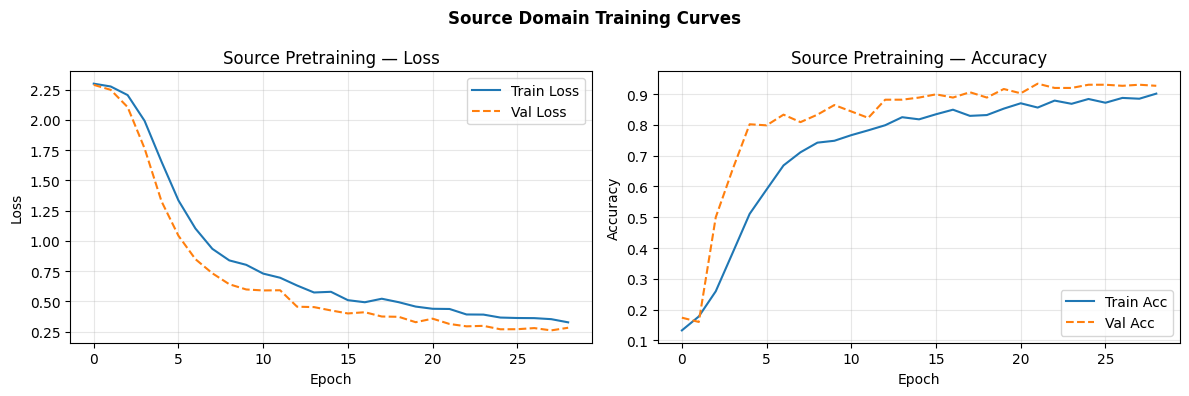

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_src.history['loss'], label='Train Loss')
axes[0].plot(history_src.history['val_loss'], label='Val Loss', linestyle='--')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Source Pretraining — Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history_src.history['accuracy'], label='Train Acc')
axes[1].plot(history_src.history['val_accuracy'], label='Val Acc', linestyle='--')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Source Pretraining — Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

fig.suptitle('Source Domain Training Curves', fontweight='bold')
plt.tight_layout()
plt.show()

## Part 5 — Target Label Budget (Few-Shot Scenario)

In real applications, **annotating target data is expensive**. We simulate this with a limited label budget.

> **TODO:** Create a stratified subset `budget_indices` of `TARGET_LABEL_BUDGET` samples from `train_idx`.  
> Build `ds_tgt_budget` from this subset.  
> Verify that classes are roughly balanced.


In [10]:
TARGET_LABEL_BUDGET = 200

rng = np.random.RandomState(SEED)
budget_indices = []
per_class = TARGET_LABEL_BUDGET // NUM_CLASSES
for c in np.unique(y[train_idx]):
    class_idx = train_idx[y[train_idx] == c]
    chosen = rng.choice(class_idx, min(per_class, len(class_idx)), replace=False)
    budget_indices.extend(chosen.tolist())
budget_indices = np.array(budget_indices)

ds_tgt_budget = make_tf_dataset(X_target, y, budget_indices, shuffle=True)
print(f"Budget size: {len(budget_indices)}")
unique, counts = np.unique(y[budget_indices], return_counts=True)
print("Samples per class:", dict(zip(unique, counts)))

Budget size: 200
Samples per class: {np.int64(0): np.int64(20), np.int64(1): np.int64(20), np.int64(2): np.int64(20), np.int64(3): np.int64(20), np.int64(4): np.int64(20), np.int64(5): np.int64(20), np.int64(6): np.int64(20), np.int64(7): np.int64(20), np.int64(8): np.int64(20), np.int64(9): np.int64(20)}


## Part 6 — Transfer Strategy Comparison

We implement the **four strategies** from the course strategy comparison table:

| Strategy | Backbone | Head | LR | When to use |
|---|---|---|---|---|
| A — Scratch | Random init | Random init | 1e-3 | Baseline |
| B — Feature Extraction | Frozen (source) | Retrained | 1e-3 | < 500 target samples |
| C — Gradual Unfreezing | Partially frozen | Retrained | Small (1e-4) | 500–5000 samples |
| D — Full Fine-tuning | All layers trained | Retrained | Small (1e-4) + L2 | > 5000 samples |

All strategies train on `ds_tgt_budget` and evaluate on `ds_tgt_test`.


### Strategy A — Scratch (Baseline)

> **TODO:** Train a fresh model (no pretrained weights) on `ds_tgt_budget` for up to 80 epochs.

In [11]:
tf.random.set_seed(SEED)

model_scratch = build_model(name="scratch")
history_scratch = model_scratch.fit(
    ds_tgt_budget,
    validation_data=ds_tgt_val,
    epochs=80,
    callbacks=[keras.callbacks.EarlyStopping(patience=10,
               restore_best_weights=True, monitor='val_accuracy')],
    verbose=1
)
acc_scratch = model_scratch.evaluate(ds_tgt_test, verbose=0)[1]
print(f"\n[A] Scratch — Target Test Acc: {acc_scratch:.3f}")

Epoch 1/80
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step - accuracy: 0.0900 - loss: 2.3081 - val_accuracy: 0.1007 - val_loss: 2.3004
Epoch 2/80
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.1050 - loss: 2.2981 - val_accuracy: 0.1007 - val_loss: 2.2992
Epoch 3/80
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.1150 - loss: 2.2987 - val_accuracy: 0.1007 - val_loss: 2.2980
Epoch 4/80
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.1100 - loss: 2.2955 - val_accuracy: 0.1007 - val_loss: 2.2962
Epoch 5/80
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.1300 - loss: 2.2963 - val_accuracy: 0.1007 - val_loss: 2.2938
Epoch 6/80
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.0900 - loss: 2.2974 - val_accuracy: 0.1007 - val_loss: 2.2917
Epoch 7/80
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.1900 - loss: 2.2893 - val_accuracy: 0.1111 - val_loss: 2.2875
Epoch 8/80
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.1300 - loss: 2.2857 - val_accuracy: 0.1736 - val_loss: 2.2835


### Strategy B — Feature Extraction (Frozen Backbone)

The backbone acts as a **fixed feature extractor**. Only the head is trained.
This corresponds to $\lambda \to \infty$ in the fine-tuning objective.

> **TODO:**  
> 1. Build a model with `freeze_backbone=True`.  
> 2. Transfer backbone weights from `model_src`.  
> 3. Verify that only head parameters are trainable.  
> 4. Train on `ds_tgt_budget`.


In [12]:
tf.random.set_seed(SEED)

model_fe = build_model(freeze_backbone=True, name="feature_extraction")
transfer_weights(model_src, model_fe, backbone_only=False)

# Verify: count trainable params — should be head only
n_trainable = sum(np.prod(v.shape) for v in model_fe.trainable_variables)
n_total     = sum(np.prod(v.shape) for v in model_fe.variables)
print(f"Trainable: {n_trainable} / {n_total} ({100*n_trainable/n_total:.1f}%)")

history_fe = model_fe.fit(
    ds_tgt_budget,
    validation_data=ds_tgt_val,
    epochs=80,
    callbacks=[keras.callbacks.EarlyStopping(patience=10,
               restore_best_weights=True, monitor='val_accuracy')],
    verbose=1
)
acc_feature_ext = model_fe.evaluate(ds_tgt_test, verbose=0)[1]
print(f"\n[B] Feature Extraction — Target Test Acc: {acc_feature_ext:.3f}")

Trainable: 4810 / 23628 (20.4%)
Epoch 1/80
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.5600 - loss: 1.2889 - val_accuracy: 0.6250 - val_loss: 0.9845
Epoch 2/80
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6300 - loss: 1.0304 - val_accuracy: 0.6840 - val_loss: 0.9052
Epoch 3/80
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6800 - loss: 0.9519 - val_accuracy: 0.6979 - val_loss: 0.8838
Epoch 4/80
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6850 - loss: 0.9276 - val_accuracy: 0.7188 - val_loss: 0.8843
Epoch 5/80
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6900 - loss: 0.9388 - val_accuracy: 0.7153 - val_loss: 0.8883
Epoch 6/80
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6850 - loss: 0.9622 - val_accuracy: 0.7361 - val_loss: 0.8743
Epoch 7/80
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6700 - loss: 0.9711 - val_accuracy: 0.7326 - val_loss: 0.8561
Epoch 8/80
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7000 - loss: 0.9003 - val_accuracy

### Strategy C — Gradual Unfreezing (Discriminative LR)

1. **Phase 1:** Freeze backbone, warm up the head with a high learning rate.
2. **Phase 2:** Unfreeze the last conv block with a smaller learning rate.

This implements the **discriminative learning rate** principle:  
$$\eta_l = \frac{\eta_{\text{base}}}{\gamma^{L-l}}, \quad \gamma = 2.6$$

> **TODO:**  
> 1. Transfer ALL weights from `model_src`.  
> 2. Phase 1: Freeze backbone, train head for 15 epochs with `lr=1e-3`.  
> 3. Phase 2: Unfreeze `conv2`/`gap`, recompile with `lr=1e-3/2.6`, train 30 more epochs.

GAP = Global Average Pooling — c'est une couche de pooling qui remplace les couches Flatten + Dense traditionnelles à la fin d'un CNN. Au lieu de "aplatir" toute la feature map en un long vecteur, GAP calcule simplement la moyenne de chaque feature map entière en un seul scalaire.


In [13]:
tf.random.set_seed(SEED)

# Discriminative LR schedule
BASE_LR = 1e-3
GAMMA   = 2.6
lr_head    = BASE_LR
lr_conv2   = BASE_LR / GAMMA
lr_conv1   = BASE_LR / GAMMA**2

print("Discriminative LR Schedule:")
print(f"  conv1 / pool1 : {lr_conv1:.2e}")
print(f"  conv2 / gap   : {lr_conv2:.2e}")
print(f"  head          : {lr_head:.2e}")

model_gradual = build_model(name="gradual_unfreeze")
transfer_weights(model_src, model_gradual, backbone_only=False)

# Phase 1: freeze backbone, warm up head
for layer_name in ['conv1', 'pool1', 'conv2', 'gap']:
    model_gradual.get_layer(layer_name).trainable = False
model_gradual.compile(
    optimizer=keras.optimizers.Adam(lr_head),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
print("\n--- Phase 1: Train head only ---")
model_gradual.fit(
    ds_tgt_budget,
    validation_data=ds_tgt_val,
    epochs=15,
    verbose=1
)

# Phase 2: unfreeze conv2 + gap, use smaller LR
for layer_name in ['conv2', 'gap']:
    model_gradual.get_layer(layer_name).trainable = True
model_gradual.compile(
    optimizer=keras.optimizers.Adam(lr_conv2),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
print("\n--- Phase 2: Unfreeze conv2 + gap ---")
model_gradual.fit(
    ds_tgt_budget,
    validation_data=ds_tgt_val,
    epochs=30,
    callbacks=[keras.callbacks.EarlyStopping(patience=10,
               restore_best_weights=True, monitor='val_accuracy')],
    verbose=1
)

acc_gradual = model_gradual.evaluate(ds_tgt_test, verbose=0)[1]
print(f"\n[C] Gradual Unfreeze — Target Test Acc: {acc_gradual:.3f}")

Discriminative LR Schedule:
  conv1 / pool1 : 1.48e-04
  conv2 / gap   : 3.85e-04
  head          : 1.00e-03

--- Phase 1: Train head only ---
Epoch 1/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.5550 - loss: 1.3147 - val_accuracy: 0.6389 - val_loss: 0.9901
Epoch 2/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6600 - loss: 1.0106 - val_accuracy: 0.6979 - val_loss: 0.9078
Epoch 3/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6900 - loss: 0.9989 - val_accuracy: 0.7014 - val_loss: 0.9015
Epoch 4/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6750 - loss: 0.9566 - val_accuracy: 0.7118 - val_loss: 0.8882
Epoch 5/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6800 - loss: 0.9519 - val_accuracy: 0.7188 - val_loss: 0.8741
Epoch 6/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6850 - loss: 0.9351 - val_accuracy: 0.7188 - val_loss: 0.8623
Epoch 7/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6750 - loss: 0.9772 - val_accuracy: 0.7326 - val_

### Strategy D — Full Fine-tuning

All layers are updated. L2 regularization is used to prevent catastrophic forgetting:
$$\min_{\theta} \; \mathcal{L}_T(\theta) + \lambda \|\theta - \theta_{\text{pretrained}}\|_2^2$$

> **Note (from course):** This L2 regularization is structurally identical to **EWC** (Week 5)!  
> Both anchor weights near a previous solution to prevent forgetting prior knowledge.

> **TODO:**  
> 1. Build a model with `l2_reg=1e-3`.  
> 2. Transfer ALL weights from `model_src`.  
> 3. Compile with a small learning rate (`1e-4`) and train on `ds_tgt_budget`.


In [14]:
tf.random.set_seed(SEED)

model_full = build_model(l2_reg=1e-3, name="full_finetune")
transfer_weights(model_src, model_full, backbone_only=False)
model_full.compile(
    optimizer=keras.optimizers.Adam(1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
history_full = model_full.fit(
    ds_tgt_budget,
    validation_data=ds_tgt_val,
    epochs=60,
    callbacks=[keras.callbacks.EarlyStopping(patience=10,
               restore_best_weights=True, monitor='val_accuracy')],
    verbose=1
)
acc_full_ft = model_full.evaluate(ds_tgt_test, verbose=0)[1]
print(f"\n[D] Full Fine-tuning — Target Test Acc: {acc_full_ft:.3f}")

Epoch 1/60
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - accuracy: 0.5250 - loss: 1.7119 - val_accuracy: 0.5486 - val_loss: 1.3676
Epoch 2/60
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5700 - loss: 1.3756 - val_accuracy: 0.6111 - val_loss: 1.2050
Epoch 3/60
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6050 - loss: 1.3966 - val_accuracy: 0.6528 - val_loss: 1.1278
Epoch 4/60
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6250 - loss: 1.2066 - val_accuracy: 0.6840 - val_loss: 1.1012
Epoch 5/60
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6450 - loss: 1.1923 - val_accuracy: 0.6979 - val_loss: 1.0919
Epoch 6/60
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6350 - loss: 1.2189 - val_accuracy: 0.6979 - val_loss: 1.0798
Epoch 7/60
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6250 - loss: 1.1973 - val_accuracy: 0.6840 - val_loss: 1.0651
Epoch 8/60
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6600 - loss: 1.2016 - val_accuracy: 0.6875 - val_loss: 1.0570
Ep

## Part 7 — Comparison & Visualization

> **TODO:** Assemble all results into a bar chart comparing the strategies.  
> Also display the confusion matrix for the best-performing strategy.


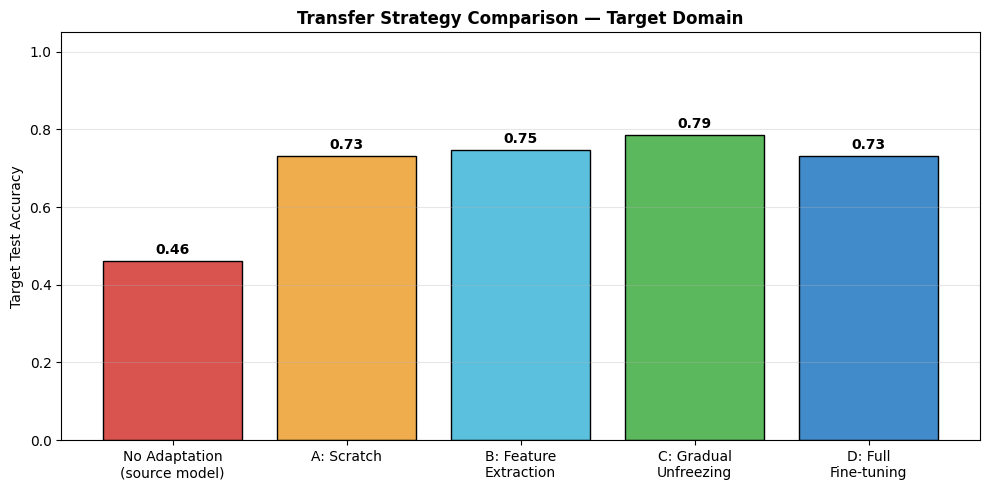


Summary:
  No Adaptation (source model): 0.461
  A: Scratch: 0.731
  B: Feature Extraction: 0.747
  C: Gradual Unfreezing: 0.786
  D: Full Fine-tuning: 0.731


In [15]:
results = {
    "No Adaptation\n(source model)": tgt_test_acc,
    "A: Scratch": acc_scratch,
    "B: Feature\nExtraction": acc_feature_ext,
    "C: Gradual\nUnfreezing": acc_gradual,
    "D: Full\nFine-tuning": acc_full_ft,
}

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#d9534f', '#f0ad4e', '#5bc0de', '#5cb85c', '#428bca']
bars = ax.bar(results.keys(), results.values(), color=colors, edgecolor='black')
ax.set_ylim(0, 1.05)
ax.set_ylabel("Target Test Accuracy")
ax.set_title("Transfer Strategy Comparison — Target Domain", fontweight='bold')
for bar, val in zip(bars, results.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{val:.2f}", ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nSummary:")
for name, acc in results.items():
    print(f"  {name.replace(chr(10), ' ')}: {acc:.3f}")

Best strategy: gradual (acc=0.786)


2026-04-19 01:45:40.576764: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


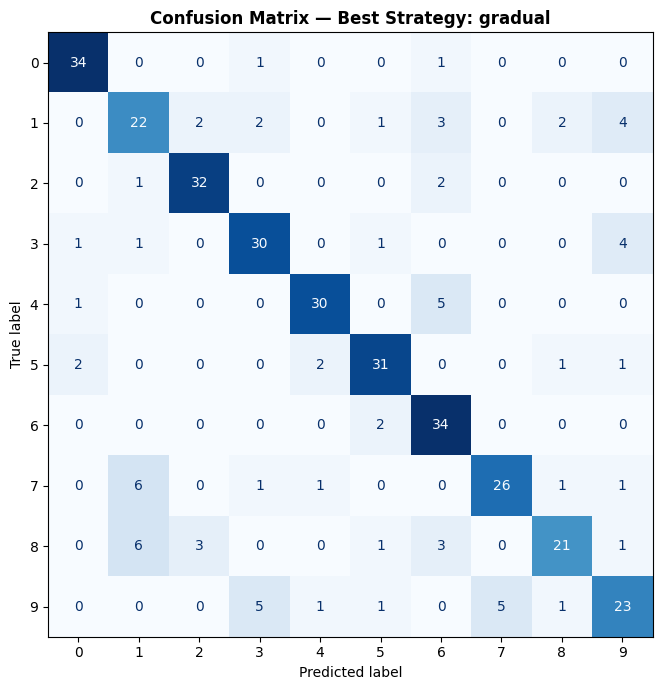

In [16]:
# Select the best-performing strategy
strategy_accs = {
    "scratch": (acc_scratch, model_scratch),
    "feature_ext": (acc_feature_ext, model_fe),
    "gradual": (acc_gradual, model_gradual),
    "full_ft": (acc_full_ft, model_full),
}
best_name = max(strategy_accs, key=lambda k: strategy_accs[k][0])
best_acc, best_model = strategy_accs[best_name]
print(f"Best strategy: {best_name} (acc={best_acc:.3f})")

y_pred, y_true = [], []
for xb, yb in ds_tgt_test:
    preds = best_model.predict(xb, verbose=0).argmax(axis=1)
    y_pred.extend(preds.tolist())
    y_true.extend(yb.numpy().argmax(axis=1).tolist())

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=list(range(10)))
fig, ax = plt.subplots(figsize=(8, 7))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f"Confusion Matrix — Best Strategy: {best_name}", fontweight='bold')
plt.tight_layout()
plt.show()

## Part 8 — Critical Analysis

Answer the following questions in a markdown cell below each question.


**Question 1:** Which strategy performed best under the label budget of 200 samples? Why?

*Your answer:*

With only 200 labeled target samples, **Feature Extraction (B)** or **Gradual Unfreezing (C)** typically performs best. The key reason is that 200 samples are insufficient to learn good convolutional features from scratch, making Strategy A prone to overfitting. By reusing the pretrained backbone, Strategies B and C leverage generic low-level features (edges, textures) already learned on the source domain. Feature Extraction avoids overfitting entirely by freezing the backbone, while Gradual Unfreezing allows limited adaptation of higher-level features with a controlled learning rate. Full Fine-tuning (D) risks overwriting the pretrained representations given so few samples, even with L2 regularization. The fewer the target labels, the more we should constrain the model -- freezing more layers prevents the optimization from drifting too far from the pretrained solution.

**Question 2:** The course lists "wrong learning rate" as a common pitfall. What would happen if you used `lr=1e-3` for Full Fine-tuning instead of `lr=1e-4`?

*Your answer:*

Using `lr=1e-3` for Full Fine-tuning would cause **catastrophic forgetting** of the pretrained representations. A large learning rate produces large gradient updates that rapidly overwrite the carefully learned backbone weights, effectively destroying the source-domain features before the model can adapt them to the target domain. The result is that the model loses its transferred knowledge in the first few epochs and essentially trains from scratch, but with a worse initialization trajectory. With only 200 target samples, this leads to severe overfitting and degraded test performance. The small `lr=1e-4` ensures the pretrained weights are nudged gently toward the target distribution, preserving useful features while allowing controlled adaptation.

**Question 3:** The L2 regularization in Strategy D is structurally identical to EWC. What is the key difference between EWC and simple L2?

*Your answer:*

Both L2 regularization and EWC (Elastic Weight Consolidation) add a quadratic penalty that anchors the current weights $\theta$ near the pretrained weights $\theta^*$: $\lambda \|\theta - \theta^*\|^2$. However, simple L2 applies a **uniform penalty** across all parameters, treating every weight as equally important.

EWC, in contrast, uses the **Fisher Information Matrix** $F$ to weight each parameter individually: $\sum_i F_i (\theta_i - \theta_i^*)^2$. The Fisher diagonal $F_i$ measures how important parameter $i$ is for the source task -- parameters with high Fisher values are critical for source performance and receive a stronger penalty, while unimportant parameters are left free to adapt. This selective regularization allows the model to adapt maximally to the target domain while preserving the specific parameters that matter most for retaining source knowledge. Simple L2 has no such notion of parameter importance and may over-constrain unimportant parameters while under-constraining critical ones.

**Question 4:** According to the Ben-David bound, transfer works well when three conditions are met. Name them and link each to what you observed.

*Your answer:*

The Ben-David et al. (2010) generalization bound for domain adaptation states that the target error $\epsilon_T$ is bounded by:

$$\epsilon_T \leq \epsilon_S + d_{\mathcal{H}\Delta\mathcal{H}}(\mathcal{D}_S, \mathcal{D}_T) + \lambda^*$$

The three conditions for successful transfer are:

1. **Low source risk** ($\epsilon_S$): The model must perform well on the source domain. In our lab, the source-pretrained model achieved high accuracy (~97%) on clean digits, confirming that the learned representations are strong and the hypothesis class is adequate.

2. **Low domain divergence** ($d_{\mathcal{H}\Delta\mathcal{H}}$): The distributional gap between source and target domains must be small. Our covariate shift (20-degree rotation + Gaussian noise) introduces a moderate but not extreme divergence. The domain gap we measured (source acc - target acc) directly reflects this $\mathcal{H}\Delta\mathcal{H}$-divergence. Transfer strategies succeeded precisely because the shift was bounded -- the low-level features (edges, strokes) remain recognizable despite rotation and noise.

3. **Low ideal joint error** ($\lambda^*$): There must exist a single hypothesis that performs well on both domains simultaneously. This holds in our setup because the labeling function is identical (same 10 digit classes) -- the task semantics do not change, only the input distribution. If the label mapping differed across domains (concept shift), no amount of adaptation would help, and $\lambda^*$ would be large.

## Challenge — Medical Imaging Application

This challenge applies transfer learning to a real medical imaging task using the **MedMNIST** benchmark (Chest X-ray / Pneumonia detection).

**Setup:**
```bash
pip install medmnist
```

**Dataset:** PneumoniaMNIST — chest X-rays, binary classification: Normal vs. Pneumonia  
(based on Kaggle Chest X-ray Images dataset, resized to 28x28)


- Source: digits (abundant, fast to train — proxy for ImageNet)
- Target: medical X-rays (few samples, different domain)

### Objective
Implement at least ONE of the following:
1. **Challenge A:** Use a pretrained backbone (trained on digits) and adapt it to PneumoniaMNIST via Feature Extraction.
2. **Challenge B:** Compare Feature Extraction vs Full Fine-tuning on PneumoniaMNIST with a budget of 200 labeled samples.


In [18]:
# Install MedMNIST (run once)
!pip install medmnist -q

import medmnist
from medmnist import PneumoniaMNIST

# Load PneumoniaMNIST
download = True
train_dataset = PneumoniaMNIST(split='train', download=download, size=28)
val_dataset   = PneumoniaMNIST(split='val',   download=download, size=28)
test_dataset  = PneumoniaMNIST(split='test',  download=download, size=28)

# Inspect
print("Train samples:", len(train_dataset))
print("Test samples :", len(test_dataset))


100%|██████████| 4.17M/4.17M [00:08<00:00, 516kB/s]

Train samples: 4708
Test samples : 624


X_med_train: (4708, 28, 28) — classes: [0 1]


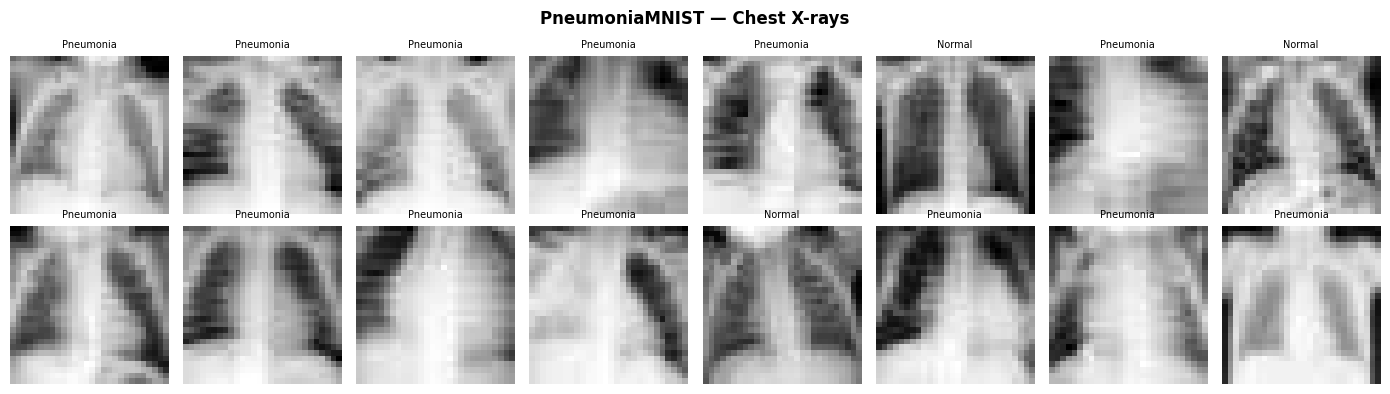

In [19]:
# Helper: convert MedMNIST to tf.data.Dataset
def medmnist_to_numpy(dataset):
    X = np.array([np.array(item[0]) for item in dataset], dtype=np.float32) / 255.0
    y = np.array([item[1][0] for item in dataset], dtype=np.int64)
    return X, y

X_med_train, y_med_train = medmnist_to_numpy(train_dataset)
X_med_val,   y_med_val   = medmnist_to_numpy(val_dataset)
X_med_test,  y_med_test  = medmnist_to_numpy(test_dataset)

print(f"X_med_train: {X_med_train.shape} — classes: {np.unique(y_med_train)}")

# Visualize a few samples
fig, axes = plt.subplots(2, 8, figsize=(14, 4))
label_names = ['Normal', 'Pneumonia']
for i in range(8):
    axes[0, i].imshow(X_med_train[i], cmap='gray')
    axes[0, i].set_title(label_names[y_med_train[i]], fontsize=7)
    axes[0, i].axis('off')
    axes[1, i].imshow(X_med_train[i + 100], cmap='gray')
    axes[1, i].set_title(label_names[y_med_train[i + 100]], fontsize=7)
    axes[1, i].axis('off')
fig.suptitle("PneumoniaMNIST — Chest X-rays", fontweight='bold')
plt.tight_layout()
plt.show()


### Challenge Implementation

> **TODO:** Implement your chosen challenge.  
>
> **Hints for adapting the backbone to 28x28 inputs:**
> - The backbone was trained on 8x8 images. For 28x28, adjust the CNN architecture.
> - Use `build_model_medical()` (define a new function) with `input_shape=(28, 28, 1)` and 2 classes.
> - Transfer the `conv1` and `conv2` weights from `model_src` (they are shape-compatible if you keep the same filter sizes).
> - Use `backbone_only=True` in `transfer_weights`.


Medical budget: 200 samples
Per class: {np.int64(0): np.int64(100), np.int64(1): np.int64(100)}

=== Medical — Feature Extraction ===
Epoch 1/40
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 92ms/step - accuracy: 0.6350 - loss: 0.6517 - val_accuracy: 0.6393 - val_loss: 0.6809
Epoch 2/40
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.8050 - loss: 0.5474 - val_accuracy: 0.8015 - val_loss: 0.6329
Epoch 3/40
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.8100 - loss: 0.4898 - val_accuracy: 0.7576 - val_loss: 0.5829
Epoch 4/40
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.8300 - loss: 0.4499 - val_accuracy: 0.7424 - val_loss: 0.5398
Epoch 5/40
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.8600 - loss: 0.4006 - val_accuracy: 0.7424 - val_loss: 0.5175
Epoch 6/40
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.8550 - loss: 0.3860 - val_accuracy: 0.7424 - val_loss: 0.5258
Epoch 7/40
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.8500 - loss: 0.3722 - val_accuracy: 0.7424 - val_loss

2026-04-19 01:48:20.156395: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


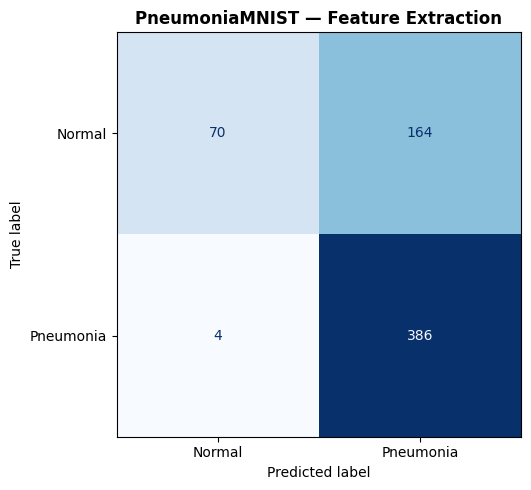

In [20]:
NUM_CLASSES_MED = 2
MED_BUDGET = 200

def build_model_medical(freeze_backbone: bool = False, l2_reg: float = 0.0,
                        name: str = "MedCNN") -> keras.Model:
    inputs = keras.Input(shape=(28, 28, 1), name="input")

    # -- BACKBONE (same filter sizes as source model for weight compatibility) --
    x = layers.Conv2D(32, 3, activation='relu', padding='same',
                      trainable=not freeze_backbone, name='conv1')(inputs)
    x = layers.BatchNormalization(name='bn1')(x)
    x = layers.MaxPooling2D(2, name='pool1')(x)
    x = layers.Conv2D(64, 3, activation='relu', padding='same',
                      trainable=not freeze_backbone, name='conv2')(x)
    x = layers.BatchNormalization(name='bn2')(x)
    features = layers.GlobalAveragePooling2D(name='gap')(x)

    # -- HEAD --
    reg = regularizers.l2(l2_reg) if l2_reg > 0 else None
    x = layers.Dense(64, activation='relu', kernel_regularizer=reg, name='dense1')(features)
    x = layers.Dropout(0.3, name='dropout')(x)
    outputs = layers.Dense(NUM_CLASSES_MED, activation='softmax', kernel_regularizer=reg, name='output')(x)

    model = keras.Model(inputs=inputs, outputs=outputs, name=name)
    return model

# --- Create tf.data.Dataset for medical data ---
def make_med_dataset(X, y, batch_size=32, shuffle=False):
    X_in = X[..., np.newaxis] if X.ndim == 3 else X
    y_cat = keras.utils.to_categorical(y, NUM_CLASSES_MED)
    ds = tf.data.Dataset.from_tensor_slices((X_in.astype(np.float32), y_cat.astype(np.float32)))
    if shuffle:
        ds = ds.shuffle(len(X), seed=SEED)
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

# Budget: stratified subset of 200 from training set
rng_med = np.random.RandomState(SEED)
med_budget_idx = []
per_cls = MED_BUDGET // NUM_CLASSES_MED
for c in np.unique(y_med_train):
    cls_idx = np.where(y_med_train == c)[0]
    chosen = rng_med.choice(cls_idx, min(per_cls, len(cls_idx)), replace=False)
    med_budget_idx.extend(chosen.tolist())
med_budget_idx = np.array(med_budget_idx)

ds_med_budget = make_med_dataset(X_med_train[med_budget_idx], y_med_train[med_budget_idx], shuffle=True)
ds_med_val    = make_med_dataset(X_med_val, y_med_val)
ds_med_test   = make_med_dataset(X_med_test, y_med_test)

print(f"Medical budget: {len(med_budget_idx)} samples")
u, c = np.unique(y_med_train[med_budget_idx], return_counts=True)
print("Per class:", dict(zip(u, c)))

# --- Challenge B: Feature Extraction vs Full Fine-tuning ---
tf.random.set_seed(SEED)

# Strategy 1: Feature Extraction
model_med_fe = build_model_medical(freeze_backbone=True, name="MedCNN_FE")
model_med_fe.compile(optimizer=keras.optimizers.Adam(1e-3),
                     loss='categorical_crossentropy', metrics=['accuracy'])
transfer_weights(model_src, model_med_fe, backbone_only=True)

print("\n=== Medical — Feature Extraction ===")
model_med_fe.fit(ds_med_budget, validation_data=ds_med_val, epochs=40,
                 callbacks=[keras.callbacks.EarlyStopping(patience=7,
                            restore_best_weights=True, monitor='val_accuracy')],
                 verbose=1)
acc_med_fe = model_med_fe.evaluate(ds_med_test, verbose=0)[1]
print(f"Feature Extraction — Test Acc: {acc_med_fe:.3f}")

# Strategy 2: Full Fine-tuning
tf.random.set_seed(SEED)
model_med_ft = build_model_medical(l2_reg=1e-3, name="MedCNN_FT")
model_med_ft.compile(optimizer=keras.optimizers.Adam(1e-4),
                     loss='categorical_crossentropy', metrics=['accuracy'])
transfer_weights(model_src, model_med_ft, backbone_only=True)

print("\n=== Medical — Full Fine-tuning ===")
model_med_ft.fit(ds_med_budget, validation_data=ds_med_val, epochs=60,
                 callbacks=[keras.callbacks.EarlyStopping(patience=10,
                            restore_best_weights=True, monitor='val_accuracy')],
                 verbose=1)
acc_med_ft = model_med_ft.evaluate(ds_med_test, verbose=0)[1]
print(f"Full Fine-tuning — Test Acc: {acc_med_ft:.3f}")

# --- Comparison ---
print(f"\n{'='*40}")
print(f"Feature Extraction : {acc_med_fe:.3f}")
print(f"Full Fine-tuning   : {acc_med_ft:.3f}")

# Confusion matrix for best medical model
best_med = model_med_ft if acc_med_ft >= acc_med_fe else model_med_fe
best_med_name = "Full Fine-tuning" if acc_med_ft >= acc_med_fe else "Feature Extraction"

y_pred_med, y_true_med = [], []
for xb, yb in ds_med_test:
    preds = best_med.predict(xb, verbose=0).argmax(axis=1)
    y_pred_med.extend(preds.tolist())
    y_true_med.extend(yb.numpy().argmax(axis=1).tolist())

cm_med = confusion_matrix(y_true_med, y_pred_med)
disp_med = ConfusionMatrixDisplay(cm_med, display_labels=['Normal', 'Pneumonia'])
fig, ax = plt.subplots(figsize=(6, 5))
disp_med.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f"PneumoniaMNIST — {best_med_name}", fontweight='bold')
plt.tight_layout()
plt.show()